In [11]:
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 01 — Data Acquisition

Downloads historical financial data from Yahoo Finance using `yfinance`.

**Output:** raw OHLCV data saved to `data/raw/<TICKER>.csv`

In [17]:
TICKER   = 'AAPL'
START    = '2020-01-01'
END      = '2025-12-31'
INTERVAL = '1d'       # '1d', '1wk', '1mo'

## Parameters

Set the ticker, date range, and sampling interval here.

In [18]:
df = yf.download(TICKER, start=START, end=END, interval=INTERVAL, auto_adjust=True)

# yfinance returns a MultiIndex — flatten to single-level columns
df.columns = df.columns.get_level_values(0)
df.index.name = 'Date'

print(f"Downloaded {len(df)} rows for {TICKER} ({START} to {END}, interval={INTERVAL})")
df.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 1507 rows for AAPL (2020-01-01 to 2025-12-31, interval=1d)


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928024,72.533064,71.708665,72.277548,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


## Download

In [20]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Shape: (1507, 5)

Data types:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Missing values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Basic statistics:


Price,Close,High,Low,Open,Volume
count,1507.000000,1507.000000,1507.000000,1507.000000,1.507000e+03
mean,164.716562,166.399265,162.866330,164.554635,8.457532e+07
std,49.612317,49.903709,49.268798,49.567158,5.136009e+07
min,54.213600,55.211516,51.372081,55.110034,1.791060e+07
25%,131.293922,132.726023,129.931626,131.642276,5.077930e+07
50%,163.192886,165.182726,161.874877,163.432352,7.040420e+07
75%,196.961555,199.128040,194.486974,196.651569,1.005777e+08
max,285.922455,288.350192,283.035157,285.932471,4.265100e+08


## Inspection

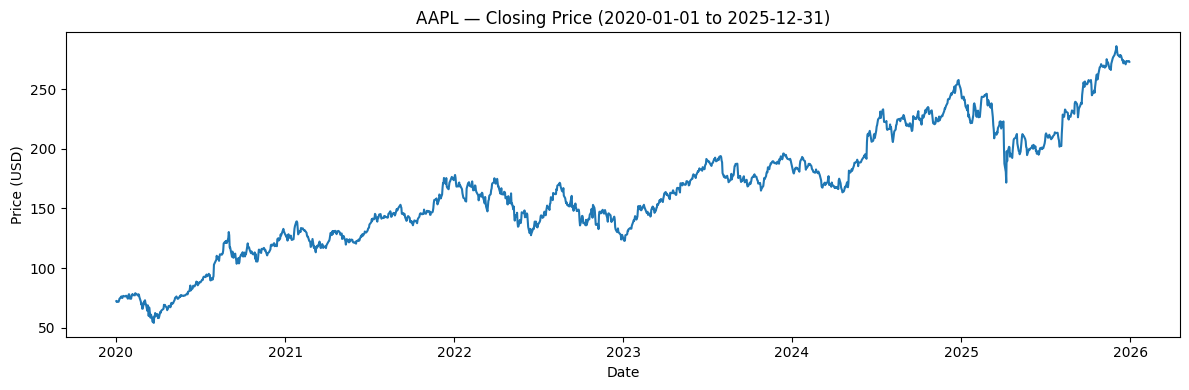

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['Close'])
ax.set_title(f'{TICKER} — Closing Price ({START} to {END})')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

## Closing Price

In [22]:
os.makedirs('../data/raw', exist_ok=True)
output_path = f'../data/raw/{TICKER}_{START}_{END}_{INTERVAL}.csv'
df.to_csv(output_path)
print(f"Saved to {output_path}")

Saved to ../data/raw/AAPL_2020-01-01_2025-12-31_1d.csv


## Save Raw Data